In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from src.scratch_ann_model_with_p import training_two_layer_ann, calculate_accuracy
from src.utils import plot_value_per_epoch
import matplotlib.pyplot as plt

In [5]:
df_train = pd.read_csv('../data/fashion-mnist_train.csv')
df_test = pd.read_csv('../data/fashion-mnist_test.csv')

In [6]:
scaler = MinMaxScaler()
labels = df_train.pop('label')
inputs = scaler.fit_transform(df_train.values)

In [7]:
y_test = df_test.pop('label')
x_test = scaler.fit_transform(df_test)

In [8]:
wl1, wl2, b1, b2, loss, epoch_no, time_per_epoch = training_two_layer_ann(inputs, labels, n_hidden=128, output_size=10, beta = 0, learning_rate=0.001, batch_size=16, n_epochs=100)

Epoch 1/100, Loss: 1.1239, Time: 1.08s
Epoch 2/100, Loss: 0.7259, Time: 1.09s
Epoch 3/100, Loss: 0.6351, Time: 1.07s
Epoch 4/100, Loss: 0.5858, Time: 1.07s
Epoch 5/100, Loss: 0.5542, Time: 1.06s
Epoch 6/100, Loss: 0.5318, Time: 1.08s
Epoch 7/100, Loss: 0.5148, Time: 1.07s
Epoch 8/100, Loss: 0.5013, Time: 1.08s
Epoch 9/100, Loss: 0.4901, Time: 1.14s
Epoch 10/100, Loss: 0.4807, Time: 1.07s
Epoch 11/100, Loss: 0.4726, Time: 1.06s
Epoch 12/100, Loss: 0.4655, Time: 1.07s
Epoch 13/100, Loss: 0.4592, Time: 1.07s
Epoch 14/100, Loss: 0.4536, Time: 1.08s
Epoch 15/100, Loss: 0.4485, Time: 1.07s
Epoch 16/100, Loss: 0.4437, Time: 1.07s
Epoch 17/100, Loss: 0.4393, Time: 1.40s
Epoch 18/100, Loss: 0.4353, Time: 1.06s
Epoch 19/100, Loss: 0.4314, Time: 1.06s
Epoch 20/100, Loss: 0.4277, Time: 1.06s
Epoch 21/100, Loss: 0.4243, Time: 1.06s
Epoch 22/100, Loss: 0.4211, Time: 1.08s
Epoch 23/100, Loss: 0.4180, Time: 1.07s
Epoch 24/100, Loss: 0.4151, Time: 1.07s
Epoch 25/100, Loss: 0.4122, Time: 1.07s
Epoch 26/

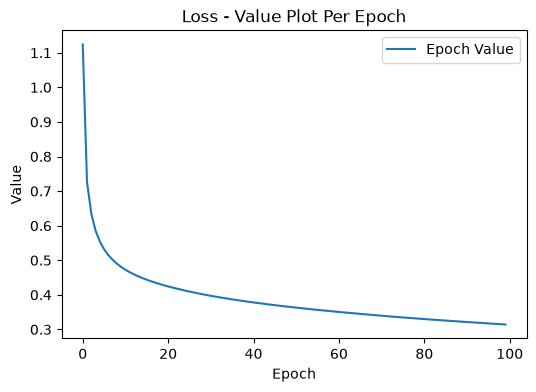

np.float64(0.8774)

In [10]:
plot_value_per_epoch(loss, title="Loss")
calculate_accuracy(wl1, wl2, b1, b2, x_test, y_test)

In [11]:
wl1, wl2, b1, b2, loss, epoch_no, time_per_epoch = training_two_layer_ann(inputs, labels, n_hidden=128, output_size=10, learning_rate=0.001, batch_size=16, n_epochs=100)

Epoch 1/100, Loss: 0.6481, Time: 1.08s
Epoch 2/100, Loss: 0.4697, Time: 1.08s
Epoch 3/100, Loss: 0.4305, Time: 1.08s
Epoch 4/100, Loss: 0.4064, Time: 1.07s
Epoch 5/100, Loss: 0.3888, Time: 1.08s
Epoch 6/100, Loss: 0.3751, Time: 1.07s
Epoch 7/100, Loss: 0.3635, Time: 1.07s
Epoch 8/100, Loss: 0.3533, Time: 1.09s
Epoch 9/100, Loss: 0.3442, Time: 1.19s
Epoch 10/100, Loss: 0.3359, Time: 1.08s
Epoch 11/100, Loss: 0.3286, Time: 1.09s
Epoch 12/100, Loss: 0.3218, Time: 1.11s
Epoch 13/100, Loss: 0.3155, Time: 1.07s
Epoch 14/100, Loss: 0.3096, Time: 1.07s
Epoch 15/100, Loss: 0.3041, Time: 1.08s
Epoch 16/100, Loss: 0.2990, Time: 1.08s
Epoch 17/100, Loss: 0.2941, Time: 1.08s
Epoch 18/100, Loss: 0.2894, Time: 1.07s
Epoch 19/100, Loss: 0.2850, Time: 1.16s
Epoch 20/100, Loss: 0.2807, Time: 1.12s
Epoch 21/100, Loss: 0.2765, Time: 1.07s
Epoch 22/100, Loss: 0.2726, Time: 1.09s
Epoch 23/100, Loss: 0.2688, Time: 1.19s
Epoch 24/100, Loss: 0.2651, Time: 1.29s
Epoch 25/100, Loss: 0.2616, Time: 1.13s
Epoch 26/

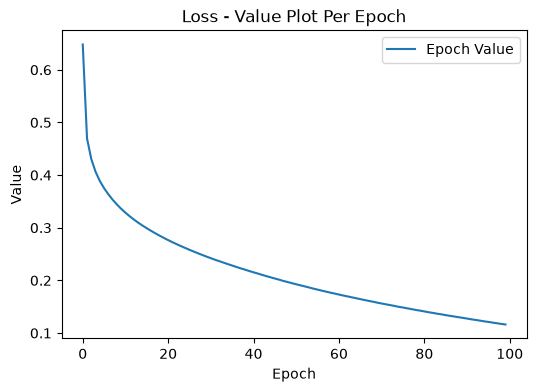

np.float64(0.8873)

In [13]:
plot_value_per_epoch(loss, title="Loss")
calculate_accuracy(wl1, wl2, b1, b2, x_test, y_test)

## Key Findings from the Scratch Implementation

During the custom NumPy implementation of a two-layer ANN, several critical mechanics of optimization were observed:

### The Importance of Weight Initialization
Initializing weights with strictly positive random numbers (np.random.random()) caused massive initial gradients, resulting in the optimizer overcorrecting and pushing weights into deep negative territory. This caused "Dying ReLU" (a permanently dead network with flat loss). Implementing He Initialization (np.random.standard_normal() * sqrt(2/n)) fixed this entirely.

### The Impact of $\beta$ (Momentum Coefficient): 
* When $\beta = 0.9$, the loss smoothly and rapidly decayed to ~0.05 by epoch 200.
* When $\beta = 0.0$ (Vanilla SGD), the loss stalled around ~0.25 by epoch 200.

Conclusion: Momentum is strictly necessary for navigating flat loss landscapes efficiently when using standard gradient descent.